# Task 2: Customer Segmentation Using Unsupervised Learning

## Objective
Cluster customers based on spending habits using K-Means clustering, visualize clusters using PCA/t-SNE, and propose marketing strategies for each segment.

## Dataset
Mall Customers Dataset

## 1. Data Loading

In [1]:
!wget -q https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2024%20-%20K-Means%20Clustering/Mall_Customers.csv -O mall_customers.csv

In [2]:
import pandas as pd
df = pd.read_csv("mall_customers.csv")
df.shape

(200, 5)

In [3]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2. Exploratory Data Analysis (EDA)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df['Genre'].value_counts()

,count
Genre,
Female,112
Male,88


### 2.1 Distribution of Key Features

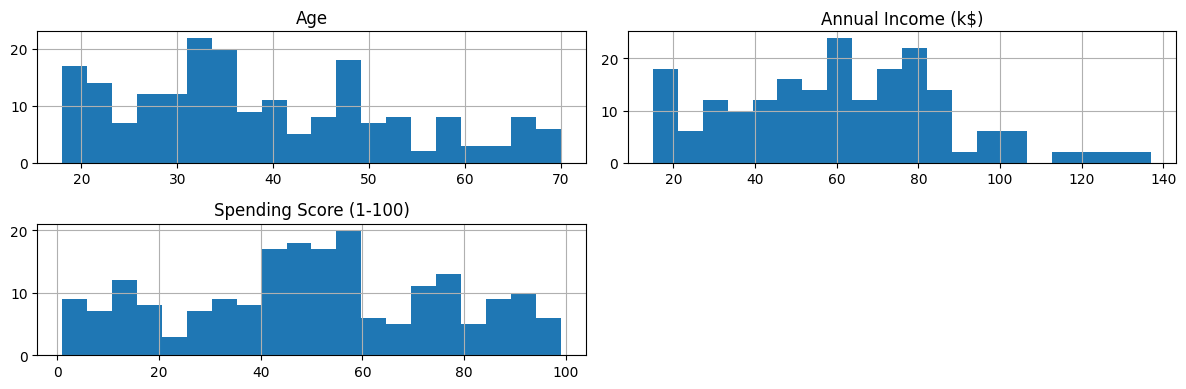

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].hist(figsize=(12, 4), bins=20)
plt.tight_layout()
plt.show()

### 2.2 Income vs Spending Score

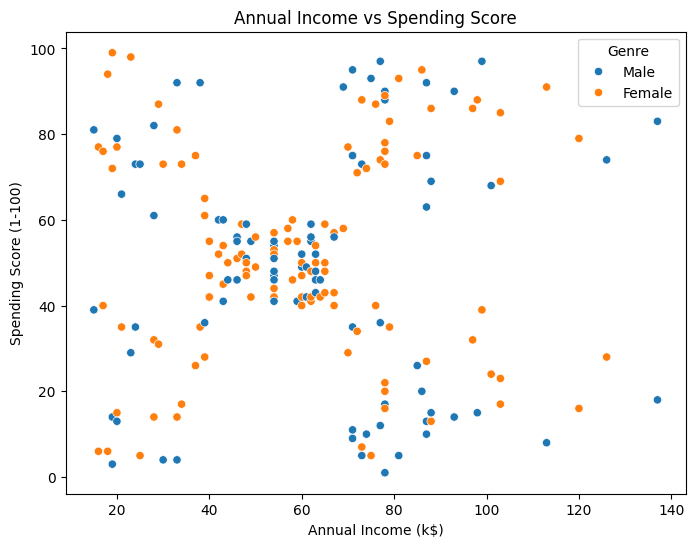

In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Genre', data=df)
plt.title('Annual Income vs Spending Score')
plt.show()

## 3. K-Means Clustering

### 3.1 Finding Optimal Number of Clusters (Elbow Method)

In [9]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


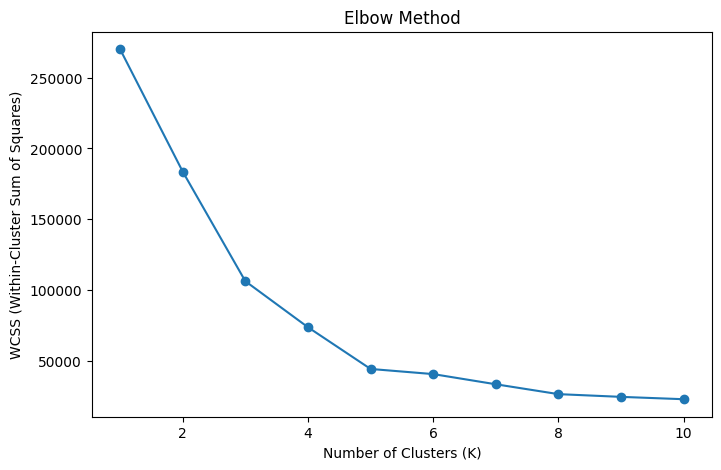

In [10]:
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.show()

### 3.2 Applying K-Means with Optimal K

In [11]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X)
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


### 3.3 Visualizing Clusters

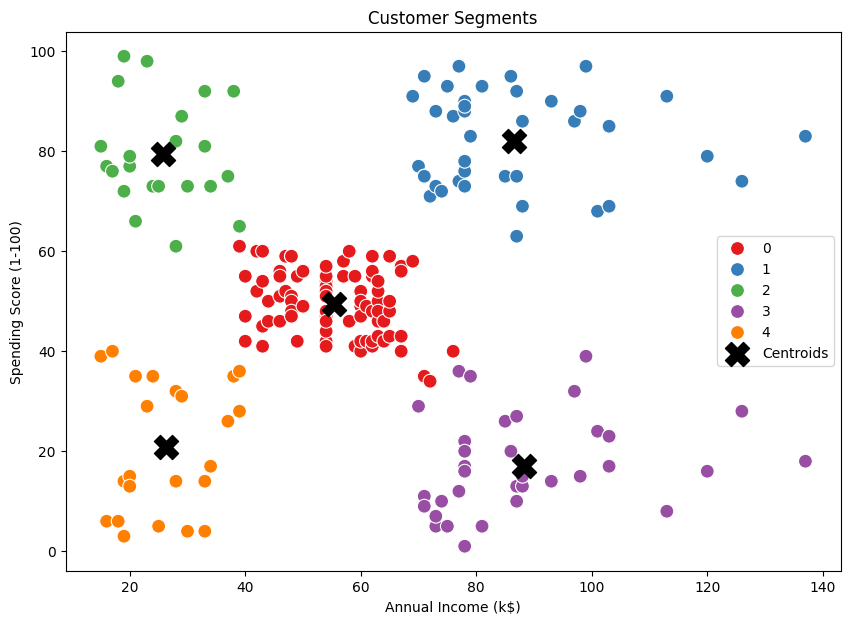

In [12]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df, palette='Set1', s=100)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='black', marker='X', label='Centroids')
plt.title('Customer Segments')
plt.legend()
plt.show()

## 4. Dimensionality Reduction with PCA
Using PCA to visualize clusters when multiple features (Age, Income, Spending Score) are considered together.

In [13]:
X_multi = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

kmeans_multi = KMeans(n_clusters=5, init='k-means++', random_state=42)
df['Cluster_Multi'] = kmeans_multi.fit_predict(X_multi)
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster,Cluster_Multi
0,1,Male,19,15,39,4,2
1,2,Male,21,15,81,2,2
2,3,Female,20,16,6,4,0
3,4,Female,23,16,77,2,2
4,5,Female,31,17,40,4,0


In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_multi)

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.45125272 0.44098465]


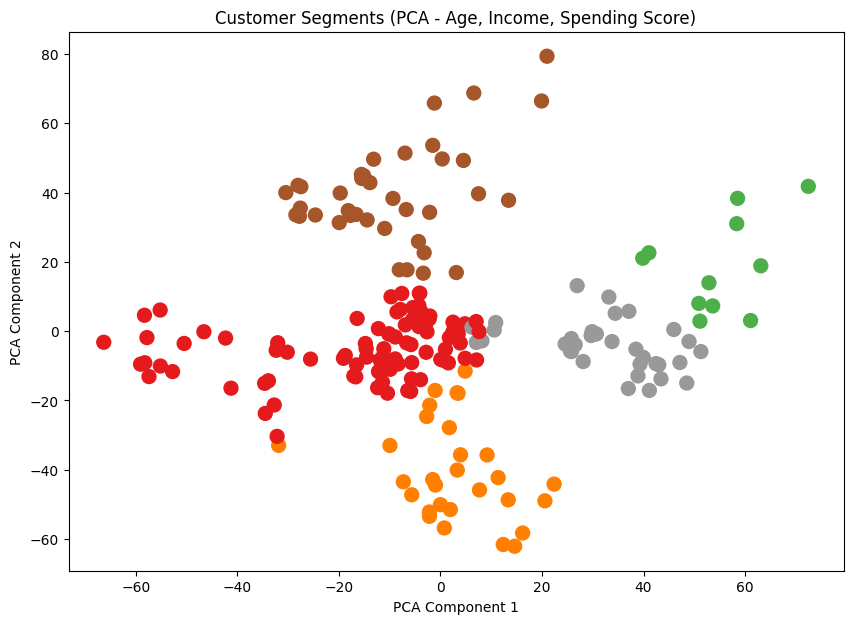

In [15]:
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster_Multi'], cmap='Set1', s=100)
plt.title('Customer Segments (PCA - Age, Income, Spending Score)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

## 5. Cluster Profiling
Analyzing average characteristics of each cluster to understand customer segments.

In [16]:
cluster_profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
cluster_profile['Count'] = df['Cluster'].value_counts()
cluster_profile

,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster,,,,
0,42.716049,55.296296,49.518519,81
1,32.692308,86.538462,82.128205,39
2,25.272727,25.727273,79.363636,22
3,41.114286,88.200000,17.114286,35
4,45.217391,26.304348,20.913043,23


## 6. Marketing Strategies by Segment

### Cluster 0: Average Customers (81 customers)
Mid-income, mid-spending group — the largest segment. Strategy: Maintain engagement with regular promotions and loyalty programs to gradually shift them toward higher spending.

### Cluster 1: High-Value Customers (39 customers)
High income, high spending — most profitable segment. Strategy: Offer premium products, exclusive memberships, and personalized services to retain loyalty.

### Cluster 2: Young Spenders (22 customers)
Low income but high spending, likely younger customers. Strategy: Target with trendy, affordable products, installment plans, and social media marketing.

### Cluster 3: Conservative High Earners (35 customers)
High income but low spending. Strategy: Investigate barriers to spending; offer targeted incentives, discounts, or value-driven messaging to increase engagement.

### Cluster 4: Low Engagement Customers (23 customers)
Low income and low spending. Strategy: Minimal marketing investment; focus on cost-effective campaigns or re-engagement offers (e.g., discount coupons) to boost activity.

## 7. Conclusion

### Key Findings:
- K-Means clustering identified 5 distinct customer segments based on income and spending behavior.
- The Elbow Method confirmed K=5 as the optimal number of clusters.
- PCA was used to visualize clusters across three dimensions (Age, Income, Spending Score), explaining ~89% of total variance with two components.
- Each segment has distinct characteristics requiring tailored marketing strategies — from high-value customers who deserve premium retention efforts, to low-engagement customers who need cost-effective re-engagement campaigns.

### Future Improvements:
- Experiment with hierarchical clustering or DBSCAN for comparison
- Incorporate additional features (e.g., purchase frequency, product categories) if available
- Validate segments with business stakeholders before deploying marketing campaigns